<a href="https://colab.research.google.com/github/ayanrasulova/rent-estimations-cv/blob/main/finetuning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR = '/content/drive/MyDrive/cv_project'
IMAGE_DIR = os.path.join(DRIVE_DIR, 'images')

print(f"Images available: {len(os.listdir(IMAGE_DIR))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images available: 8399


In [7]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [8]:
# load & clean data
df = pd.read_csv(os.path.join(DRIVE_DIR, 'listings_clean.csv'))
df['img_path'] = df['img_path'].apply(
    lambda p: os.path.join(IMAGE_DIR, os.path.basename(str(p))) if pd.notna(p) else None
)


# fix any remaining string columns
df['sqft'] = pd.to_numeric(df['sqft'].astype(str).str.replace(',', '').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price', 'img_path'])
df = df[df['img_path'].apply(os.path.exists)]

print(f"Listings with valid images: {len(df)}")
print(f"Price range: ${df['price'].min():,.0f} – ${df['price'].max():,.0f}")



Listings with valid images: 8400
Price range: $150,000 – $11,495,000


In [9]:
# dataset
class PropertyDataset(Dataset):
    def __init__(self, img_paths, prices, transform):
        self.img_paths = img_paths
        self.prices    = prices
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.img_paths[idx]).convert('RGB')
            img = self.transform(img)
        except:
            img = torch.zeros(3, 224, 224)
        price = torch.tensor(self.prices[idx], dtype=torch.float32)
        return img, price

In [10]:
# transforms
# add augmentation for training to help generalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
# prep data
df_valid = df[df['img_path'].notna() & df['img_path'].apply(os.path.exists)].copy()
df_valid['price'] = pd.to_numeric(df_valid['price'], errors='coerce')
df_valid = df_valid.dropna(subset=['price'])

# normalize prices to help training (predict in $100k units)
price_mean = df_valid['price'].mean()
price_std  = df_valid['price'].std()
df_valid['price_norm'] = (df_valid['price'] - price_mean) / price_std

# train/val split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_valid, test_size=0.2, random_state=42)

train_dataset = PropertyDataset(train_df['img_path'].tolist(), train_df['price_norm'].tolist(), train_transform)
val_dataset   = PropertyDataset(val_df['img_path'].tolist(),   val_df['price_norm'].tolist(),   val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# build model
model = models.resnet50(weights='IMAGENET1K_V1')

# freeze all layer
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last ResNet block (layer4) + final FC
for param in model.layer4.parameters():
    param.requires_grad = True

# replace final classification layer with regression head
model.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1)   # single output = price
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
print(f"Using device: {device}")

Train: 6720 | Val: 1680
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


Using device: cuda


In [12]:
# training loop
# only optimize unfrozen parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
criterion = nn.MSELoss()

In [13]:
# training loop
EPOCHS = 20

for epoch in range(EPOCHS):
    # train
    model.train()
    train_loss = 0
    for imgs, prices in train_loader:
        imgs, prices = imgs.to(device), prices.to(device)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, prices)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, prices in val_loader:
            imgs, prices = imgs.to(device), prices.to(device)
            preds = model(imgs).squeeze(1)
            val_loss += criterion(preds, prices).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    # convert loss back to dollars (denormalize)
    train_mae_dollars = (train_loss ** 0.5) * price_std
    val_mae_dollars   = (val_loss   ** 0.5) * price_std

    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | ~Val $RMSE: ${val_mae_dollars:,.0f}")

Epoch 01/20 | Train Loss: 0.8453 | Val Loss: 0.7873 | ~Val $RMSE: $1,181,076
Epoch 02/20 | Train Loss: 0.5924 | Val Loss: 0.8520 | ~Val $RMSE: $1,228,669
Epoch 03/20 | Train Loss: 0.3691 | Val Loss: 0.8359 | ~Val $RMSE: $1,217,015
Epoch 04/20 | Train Loss: 0.2652 | Val Loss: 0.7041 | ~Val $RMSE: $1,116,928
Epoch 05/20 | Train Loss: 0.1975 | Val Loss: 0.6902 | ~Val $RMSE: $1,105,890
Epoch 06/20 | Train Loss: 0.1582 | Val Loss: 0.7314 | ~Val $RMSE: $1,138,371
Epoch 07/20 | Train Loss: 0.1284 | Val Loss: 0.7099 | ~Val $RMSE: $1,121,571
Epoch 08/20 | Train Loss: 0.1095 | Val Loss: 0.6825 | ~Val $RMSE: $1,099,670
Epoch 09/20 | Train Loss: 0.0960 | Val Loss: 0.6767 | ~Val $RMSE: $1,095,015
Epoch 10/20 | Train Loss: 0.0822 | Val Loss: 0.6769 | ~Val $RMSE: $1,095,169
Epoch 11/20 | Train Loss: 0.0749 | Val Loss: 0.6908 | ~Val $RMSE: $1,106,349
Epoch 12/20 | Train Loss: 0.0682 | Val Loss: 0.6774 | ~Val $RMSE: $1,095,577
Epoch 13/20 | Train Loss: 0.0669 | Val Loss: 0.6842 | ~Val $RMSE: $1,101,027

In [14]:
# save to drive
torch.save(model.state_dict(), os.path.join(DRIVE_DIR, 'resnet50_finetuned.pth'))
print("Saved to Drive!")

Saved to Drive!


In [15]:

# extract features
model.eval()
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)

extract_dataset = PropertyDataset(df_valid['img_path'].tolist(), df_valid['price_norm'].tolist(), val_transform)
extract_loader  = DataLoader(extract_dataset, batch_size=32, shuffle=False, num_workers=2)

all_features = []
with torch.no_grad():
    for imgs, _ in extract_loader:
        imgs     = imgs.to(device)
        features = feature_extractor(imgs).squeeze(-1).squeeze(-1)
        all_features.append(features.cpu().numpy())

visual_features_ft = np.vstack(all_features)
np.save(os.path.join(DRIVE_DIR, 'visual_features_finetuned.npy'), visual_features_ft)
print(f"Fine-tuned features shape: {visual_features_ft.shape}")

Fine-tuned features shape: (8400, 2048)


In [16]:
from sklearn.decomposition import PCA

# reduce 2048 CNN dims down to 100
pca = PCA(n_components=100)
visual_features_pca = pca.fit_transform(visual_features_ft)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

TABULAR  = ['beds', 'baths', 'sqft', 'year_built', 'walk_score', 'bike_score', 'parking_total_spaces']
df_model = pd.get_dummies(df_valid, columns=['property_type', 'region'], drop_first=True)
ohe_cols = [c for c in df_model.columns if c.startswith('property_type_') or c.startswith('region_')]
TABULAR  = TABULAR + ohe_cols
bool_cols = [c for c in df_model.columns if df_model[c].dtype == bool]
df_model[bool_cols] = df_model[bool_cols].astype(int)

X_tab = df_model[TABULAR].apply(pd.to_numeric, errors='coerce').values
X_combined = np.hstack([X_tab, visual_features_pca])
y = df_valid['price'].values

imputer    = SimpleImputer(strategy='median')
X_combined = imputer.fit_transform(X_combined)

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

print(f"\n{'Model':20s} | {'MAE':>12} | {'RMSE':>12} | {'R²':>6}")
print("-" * 60)
for name, m in models_cv.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:20s} | ${mae:>10,.0f} | ${rmse:>10,.0f} | {r2:.3f}")

Variance explained: 85.91%

Model                |          MAE |         RMSE |     R²
------------------------------------------------------------
Linear Regression    | $   589,842 | $ 1,014,075 | 0.396
Decision Tree        | $   568,351 | $ 1,078,428 | 0.317
Random Forest        | $   556,692 | $ 1,079,331 | 0.316


In [17]:
# vision only
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import numpy as np

# load fine-tuned visual features
visual_features_ft = np.load(os.path.join(DRIVE_DIR, 'visual_features_finetuned.npy'))

# reduce dimensions
pca = PCA(n_components=100)
visual_features_pca = pca.fit_transform(visual_features_ft)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

X_vision = visual_features_pca
y = df_valid['price'].values

imputer  = SimpleImputer(strategy='median')
X_vision = imputer.fit_transform(X_vision)

X_train, X_test, y_train, y_test = train_test_split(X_vision, y, test_size=0.2, random_state=42)

models_vision = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

print(f"\n{'Model':20s} | {'MAE':>12} | {'RMSE':>12} | {'R²':>6}")
print("-" * 60)
for name, m in models_vision.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:20s} | ${mae:>10,.0f} | ${rmse:>10,.0f} | {r2:.3f}")

Variance explained: 85.91%

Model                |          MAE |         RMSE |     R²
------------------------------------------------------------
Linear Regression    | $   683,108 | $ 1,139,616 | 0.238
Decision Tree        | $   595,802 | $ 1,095,572 | 0.295
Random Forest        | $   588,883 | $ 1,096,150 | 0.295


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


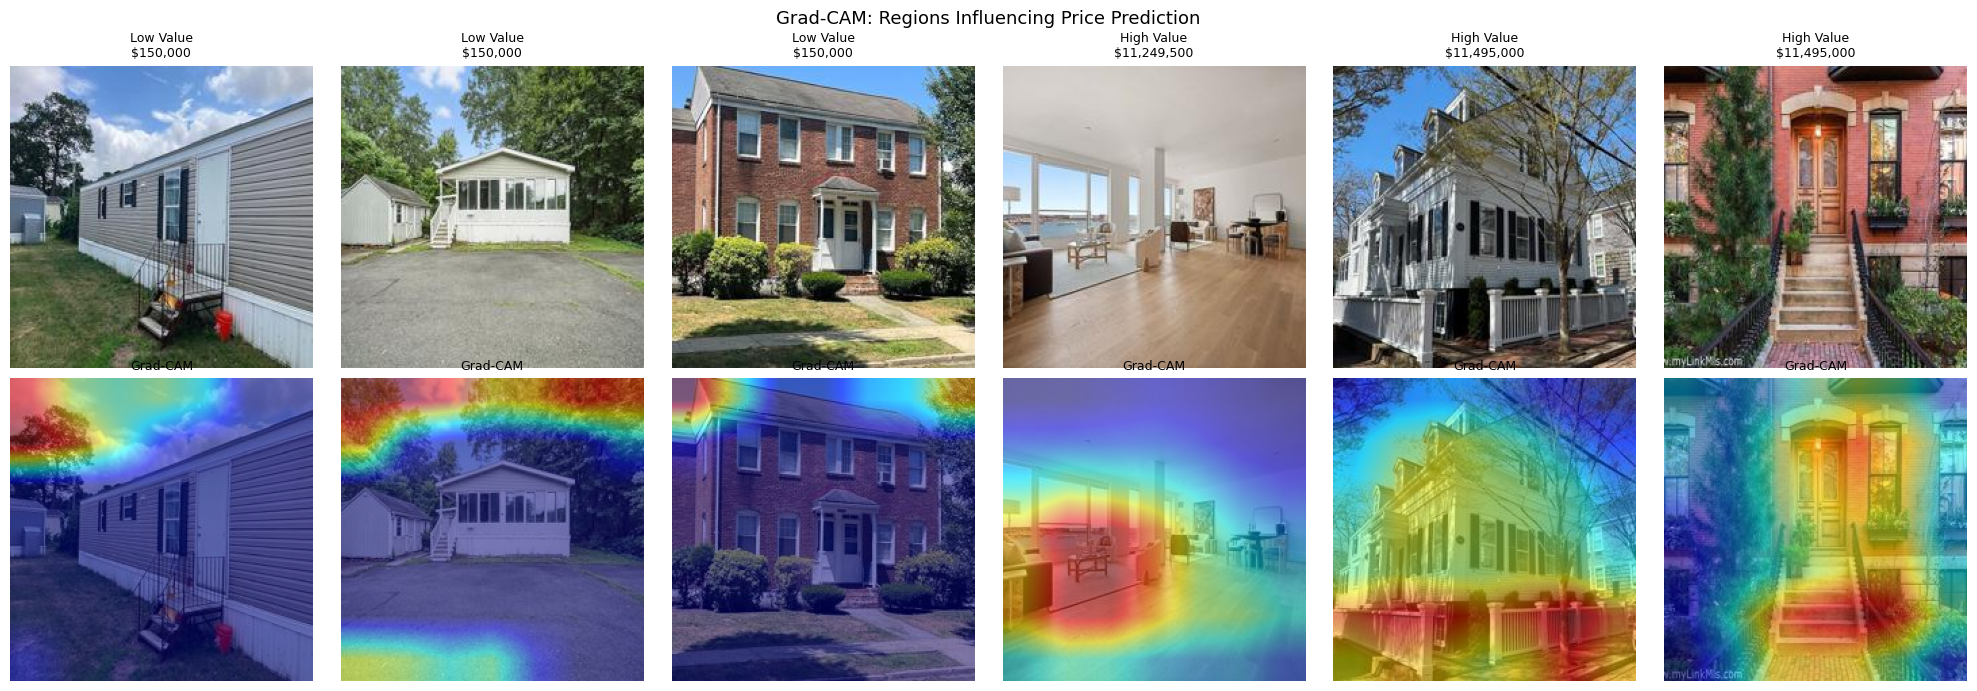

Saved gradcam.png


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output.backward(torch.ones_like(output))

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# setup:
# hook into the last conv layer of layer4
gradcam = GradCAM(model, model.layer4[-1].conv3)

# show 6 sample properties (3 high value, 3 low value)
df_valid_sorted = df_valid.sort_values('price')
samples = pd.concat([
    df_valid_sorted.head(3),   # cheapest
    df_valid_sorted.tail(3)    # most expensive
]).reset_index(drop=True)
labels = ['Low', 'Low', 'Low', 'High', 'High', 'High']

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, (_, row) in enumerate(samples.iterrows()):
    img_pil = Image.open(row['img_path']).convert('RGB').resize((224, 224))
    img_np  = np.array(img_pil)

    input_tensor = val_transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    cam = gradcam.generate(input_tensor)

    # og image
    axes[0][i].imshow(img_np)
    axes[0][i].set_title(f"{labels[i]} Value\n${row['price']:,.0f}", fontsize=9)
    axes[0][i].axis('off')

    # Grad-CAM overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)
    axes[1][i].imshow(overlay)
    axes[1][i].set_title(f"Grad-CAM", fontsize=9)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Original', fontsize=10)
axes[1][0].set_ylabel('Grad-CAM', fontsize=10)

plt.suptitle('Grad-CAM: Regions Influencing Price Prediction', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'gradcam.png'), dpi=150)
plt.show()
print("Saved gradcam.png")